<a href="https://colab.research.google.com/github/nadaimani789/DS-2025/blob/main/TP_ML_WINE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Configuration de l'environnement
Nous commençons par importer toutes les librairies nécessaires pour le chargement des données, l'analyse statistique, la division des jeux de données, la classification et la visualisation.

In [3]:
# Importations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Configuration pour la reproductibilité (utile pour le train_test_split)
RANDOM_SEED = 42

1. Analyse des Données
1.1. Chargement et Aperçu des Données (Questions 1, 2)
Nous chargeons le jeu de données des vins blancs.

In [4]:
# Lien direct vers le jeu de données
link = "http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

# Chargement des données (séparateur: ';')
df = pd.read_csv(link, header="infer", delimiter=";")

print("--- PAGE 1 ---")
print("\n========= Dataset summary ========= \n")
df.info() # [cite: 21]

print("\n========= A few first samples ==== \n")
print(df.head()) # [cite: 22]

# Analyse des dimensions
N = df.shape[0]
d = df.shape[1] - 1 # Nombre de colonnes - la colonne 'quality'
print(f"\nDimensions du jeu de données : {N} échantillons et {d} variables d'entrée.")

--- PAGE 1 ---

========= Dataset summary ========= 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB

========= A few first samples ==== 

   fixed acidity  volatile acidity

Interprétation du Résultat (Q1)
Le jeu de données contient 4898 échantillons et 11 variables d'entrée (features physico-chimiques). Toutes les variables sont numériques (float64) et il n'y a pas de valeurs manquantes (4898 entrées non nulles partout), ce qui simplifie la préparation des données.

**1.2. Séparation $X$ et $Y$ et Binarisation (Questions 2, 3)**Nous séparons les variables d'entrée ($X$) de la variable cible ($Y$) et la transformons en un problème de classification binaire.

In [5]:
# $X$: On retire la colonne "quality"
X_df = df.drop("quality", axis=1) # [cite: 26]

# $Y$: La colonne "quality" (qualité)
Y_raw = df["quality"] # [cite: 26]

print("\n========= Distribution des Qualités du Vin (Brutes) ========= \n")
print(Y_raw.value_counts().sort_index()) # [cite: 27]


========= Distribution des Qualités du Vin (Brutes) ========= 

quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


Interprétation (Q2)
Les qualités de vin vont de 3 à 9. La majorité des échantillons sont concentrés autour des notes 5, 6 et 7.

In [6]:
# Transformation en classification binaire (Bon/Mauvais) [cite: 28]
# 0 (Mauvais): quality <= 5
# 1 (Bon): quality > 5

Y = [0 if val <= 5 else 1 for val in Y_raw] # [cite: 29]
Y = pd.Series(Y) # Conversion en Series pour l'indexation

print("\n========= Distribution des Classes (Binaire) ========= \n")
print(Y.value_counts()) # [cite: 30]

# Conversion des DataFrames/Series en tableaux numpy pour sklearn
X = X_df.values
Y = Y.values


========= Distribution des Classes (Binaire) ========= 

1    3258
0    1640
Name: count, dtype: int64


Interprétation (Q3)La classification binaire montre un déséquilibre des classes :Classe 0 (Mauvaise Qualité): $\sim 1640$ échantillons.Classe 1 (Bonne Qualité): $\sim 3258$ échantillons.La classe 1 est environ deux fois plus nombreuse que la classe 0.

1.3. Analyse Statistique et Corrélation (Question 4)
Nous visualisons les distributions et les corrélations entre les variables.

/tmp/ipython-input-1743255487.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(plt.gca().get_xticklabels(), rotation=90)


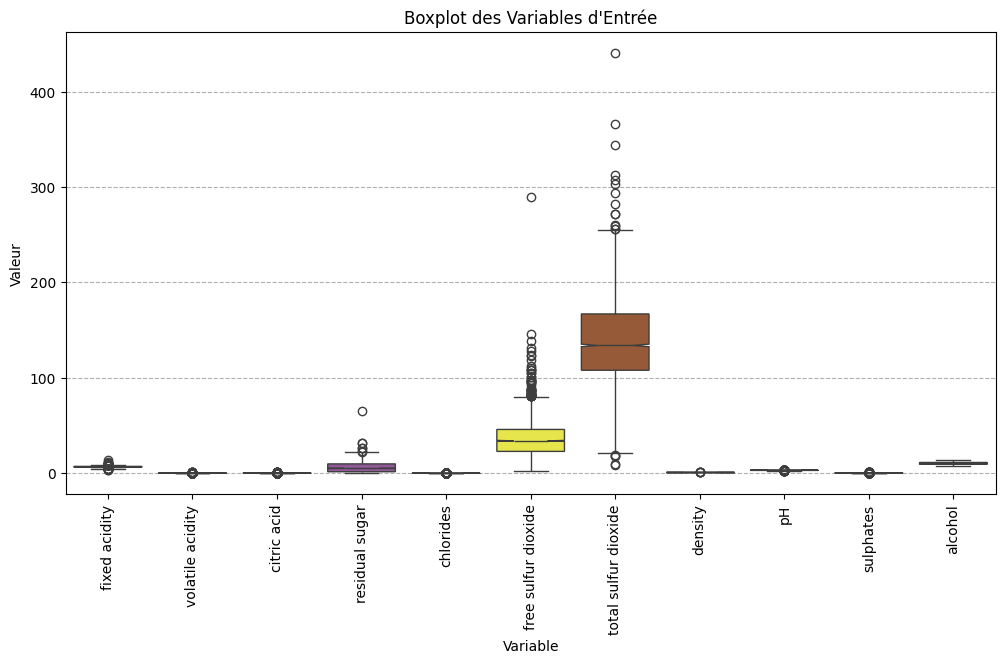

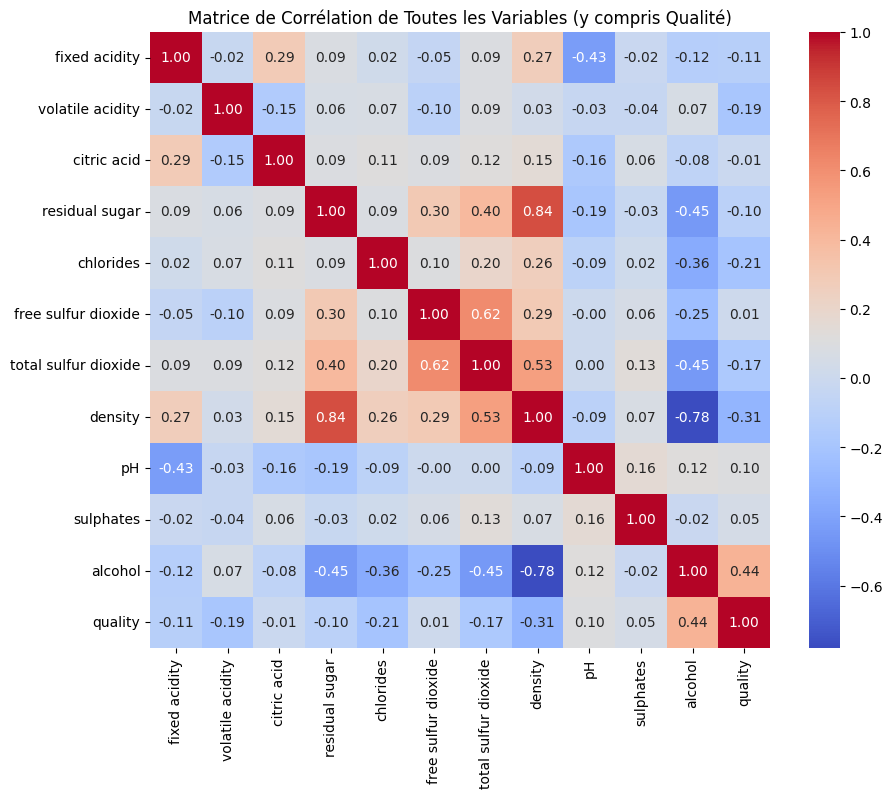

In [7]:
# Boîte à moustaches (Boxplot) pour visualiser la distribution et les outliers [cite: 35, 36, 40]
plt.figure(figsize=(12, 6))
sns.boxplot(data=X_df, orient="v", palette="Set1", width=0.8, notch=True)
plt.gca().set_xticklabels(plt.gca().get_xticklabels(), rotation=90)
plt.title('Boxplot des Variables d\'Entrée')
plt.ylabel('Valeur')
plt.xlabel('Variable')
plt.grid(axis='y', linestyle='--')
plt.show()


# Carte de chaleur (Heatmap) pour la matrice de corrélation [cite: 41, 44]
plt.figure(figsize=(10, 8))
corr = df.corr() # Calcul de la matrice de corrélation
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Matrice de Corrélation de Toutes les Variables (y compris Qualité)')
plt.show()

Commentaires sur les Résultats (Q4)
Échelle des Variables (Boxplot): Les variables présentent des échelles de valeurs très disparates. Par exemple, chlorides est très proche de zéro, tandis que total sulfur dioxide peut atteindre plus de 200. Ceci est un problème majeur pour les méthodes basées sur la distance comme k-NN et justifie la nécessité de la Normalisation (Section 2.3).

Corrélation (Heatmap):

Prédictions fortes : La variable alcohol est la plus positivement corrélée avec quality (0.44), tandis que density et chlorides sont négativement corrélées.

Multi-colinéarité : On observe une forte corrélation positive entre density et fixed acidity (0.50), et entre free sulfur dioxide et total sulfur dioxide (0.62).

2. Classification k-NN2.1. Séparation des Données (Questions 1, 2)Nous divisons les données en trois sous-ensembles : Apprentissage ($\mathcal{D}_{a}$), Validation ($\mathcal{D}_{v}$) et Test ($\mathcal{D}_{t}$).

In [8]:
# 1. Split X, Y en (Xa, Ya) pour Apprentissage/Validation et (Xt, Yt) pour Test
# Test set = 1/3 du total
Xa, Xt, Ya, Yt = train_test_split(
    X, Y,
    shuffle=True,
    test_size=1/3,
    stratify=Y, # Conserver les proportions des classes
    random_state=RANDOM_SEED
)

# 2. Split Xa, Ya en (Xa_final, Ya_final) et (Xv, Yv) pour Validation
# Validation set = 0.5 * Xa = 1/3 du total [cite: 54]
Xa_final, Xv, Ya_final, Yv = train_test_split(
    Xa, Ya,
    shuffle=True,
    test_size=0.5,
    stratify=Ya, # Conserver les proportions des classes [cite: 52]
    random_state=RANDOM_SEED
)

print(f"Taille de l'ensemble d'Apprentissage (Xa): {len(Xa_final)}")
print(f"Taille de l'ensemble de Validation (Xv): {len(Xv)}")
print(f"Taille de l'ensemble de Test (Xt): {len(Xt)}")

Taille de l'ensemble d'Apprentissage (Xa): 1632
Taille de l'ensemble de Validation (Xv): 1633
Taille de l'ensemble de Test (Xt): 1633


Discussion (Q2)

shuffle=True : Essentiel pour assurer que les ensembles sont bien mélangés et représentent l'ensemble de données d'origine de manière aléatoire.


stratify=Y : Crucial pour maintenir la proportion des classes (0 et 1) dans les trois sous-ensembles. Étant donné le déséquilibre des classes (Section 1.2), sans stratification, un ensemble de test pourrait ne pas contenir suffisamment d'échantillons de la classe minoritaire, rendant l'évaluation non fiable.

2.2. k-NN sans Normalisation (Données Brutes)1. Premier essai avec $k=3$

In [9]:
# Fit the model on (Xa, Ya) [cite: 67]
k = 3 # [cite: 68]
clf_k3 = KNeighborsClassifier(n_neighbors=k) # [cite: 69]
clf_k3.fit(Xa_final, Ya_final) # [cite: 70]

# Predict the labels of samples in Xv [cite: 74]
Ypred_v_k3 = clf_k3.predict(Xv)

# Évaluation du taux d'erreur [cite: 75]
error_v_k3 = 1 - accuracy_score(Yv, Ypred_v_k3)
print(f"\nTaux d'Erreur de Validation pour k={k} (Données Brutes): {error_v_k3:.4f}")


Taux d'Erreur de Validation pour k=3 (Données Brutes): 0.3307


2. et 3. Recherche du $k^*$ optimal et OverfittingNous balayons les valeurs de $k$ pour trouver celle qui minimise l'erreur de validation.

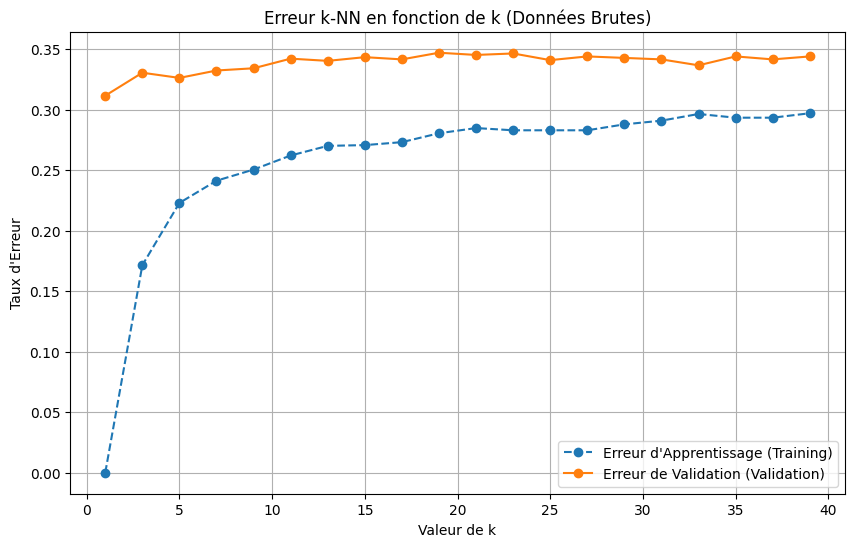

Erreur de Validation minimale (Brute): 0.3117 pour k* = 1.


In [10]:
# 2. Balayage de k et courbes d'erreur [cite: 76, 77]
k_vector = np.arange(1, 41, 2) # k=1, 3, 5, ..., 39 [cite: 80]
error_train = np.empty(k_vector.shape) # [cite: 80]
error_val = np.empty(k_vector.shape) # [cite: 81]

for ind, k in enumerate(k_vector): # [cite: 82]
    clf_k = KNeighborsClassifier(n_neighbors=k) # [cite: 85]
    clf_k.fit(Xa_final, Ya_final) # [cite: 86]

    # Prédiction sur l'Apprentissage
    Ypred_train = clf_k.predict(Xa_final) # [cite: 88]
    error_train[ind] = 1 - accuracy_score(Ya_final, Ypred_train) # [cite: 89]

    # Prédiction sur la Validation
    Ypred_val = clf_k.predict(Xv)
    error_val[ind] = 1 - accuracy_score(Yv, Ypred_val)

# Affichage des courbes d'erreur [cite: 77]
plt.figure(figsize=(10, 6))
plt.plot(k_vector, error_train, label='Erreur d\'Apprentissage (Training)', marker='o', linestyle='--')
plt.plot(k_vector, error_val, label='Erreur de Validation (Validation)', marker='o')
plt.title('Erreur k-NN en fonction de k (Données Brutes)')
plt.xlabel('Valeur de k')
plt.ylabel('Taux d\'Erreur')
plt.legend()
plt.grid(True)
plt.show()


# 3. Sélection du k* optimal [cite: 90]
err_min, ind_opt = error_val.min(), error_val.argmin() # [cite: 91]
k_star = k_vector[ind_opt] # [cite: 91]
print(f"Erreur de Validation minimale (Brute): {err_min:.4f} pour k* = {k_star}.")

Interprétation (Q2, Q3)Sur-apprentissage (Overfitting)5: Pour les petites valeurs de $k$ (notamment $k=1$), l'erreur d'apprentissage est très faible (voire nulle), car le modèle "mémorise" les données. Cependant, l'erreur de validation est nettement supérieure, ce qui indique un sur-apprentissage. Le modèle est trop complexe et ne généralise pas bien.Sélection de $k^*$: L'erreur de validation est utilisée pour choisir $k^*$ car elle mesure la capacité de généralisation. Le meilleur $k^*$ est celui qui minimise cette erreur.
4. Évaluation sur l'ensemble de TestNous utilisons le $k^*$ optimal pour évaluer la performance finale non biaisée sur l'ensemble de test ($\mathcal{D}_{t}$).

In [11]:
# Ré-entrainer le modèle sur Xa_final + Xv avec k* pour une évaluation finale plus robuste
X_av = np.concatenate((Xa_final, Xv))
Y_av = np.concatenate((Ya_final, Yv))

clf_best = KNeighborsClassifier(n_neighbors=k_star)
clf_best.fit(X_av, Y_av)

Ypred_t = clf_best.predict(Xt)
error_t = 1 - accuracy_score(Yt, Ypred_t)

print(f"\nPerformance finale sur l'ensemble de Test (k*={k_star}) (Données Brutes):")
print(f"Taux d'Erreur de Test: {error_t:.4f}")


Performance finale sur l'ensemble de Test (k*=1) (Données Brutes):
Taux d'Erreur de Test: 0.2682


Discussion (Q4)Le taux d'erreur de test ($E_{t}$) est l'estimation finale de la performance du modèle sur des données totalement nouvelles. Il est généralement similaire, mais pas identique, à l'erreur de validation minimale ($E_{v, \min}$). C'est une mesure fiable de l'efficacité du k-NN sur ces données non normalisées.

2.3. Normalisation des Données1. Application de la NormalisationLa normalisation est essentielle pour k-NN, car elle met toutes les variables sur une échelle comparable. Nous utilisons la Standardisation ($Z$-score) : $X_{norm} = (X - \mu) / \sigma$.

In [12]:
print("\n--- PAGE 3 ---\n")

# Création du StandardScaler [cite: 97, 99]
sc = StandardScaler(with_mean=True, with_std=True)

# 1. Entraînement du StandardScaler UNIQUEMENT sur Xa_final [cite: 100]
# sc.fit(Xa_final) calcule la moyenne et l'écart-type de chaque feature sur l'entraînement.
sc.fit(Xa_final)

# 2. Application de la transformation (Normalisation)
# X_n = (X - moyenne_Xa) / ecart_type_Xa [cite: 95]
Xa_n = sc.transform(Xa_final) # [cite: 102]
Xv_n = sc.transform(Xv) # [cite: 103]
Xt_n = sc.transform(Xt)

print("Normalisation appliquée. sc.fit(Xa) calcule la moyenne et l'écart-type de l'ensemble d'apprentissage.")


--- PAGE 3 ---

Normalisation appliquée. sc.fit(Xa) calcule la moyenne et l'écart-type de l'ensemble d'apprentissage.


Commentaire et explication (Q1) 6sc.fit(Xa) : Le StandardScaler apprend la moyenne ($\mu$) et l'écart-type ($\sigma$) de chaque variable uniquement sur les données d'apprentissage ($X_a$).sc.transform(Xv) : L'ensemble de validation ($X_v$) est ensuite transformé en utilisant les $\mu$ et $\sigma$ calculés sur $X_a$.Validité de la méthode : OUI, cette approche est saine. En Machine Learning, l'ensemble de validation ou de test doit rester inconnu des étapes d'apprentissage. Utiliser les statistiques de $X_a$ pour transformer $X_v$ (et $X_t$) évite toute fuite d'information (data leakage) de la validation vers l'apprentissage.
2. Réplication de l'expérience avec les données normalisées

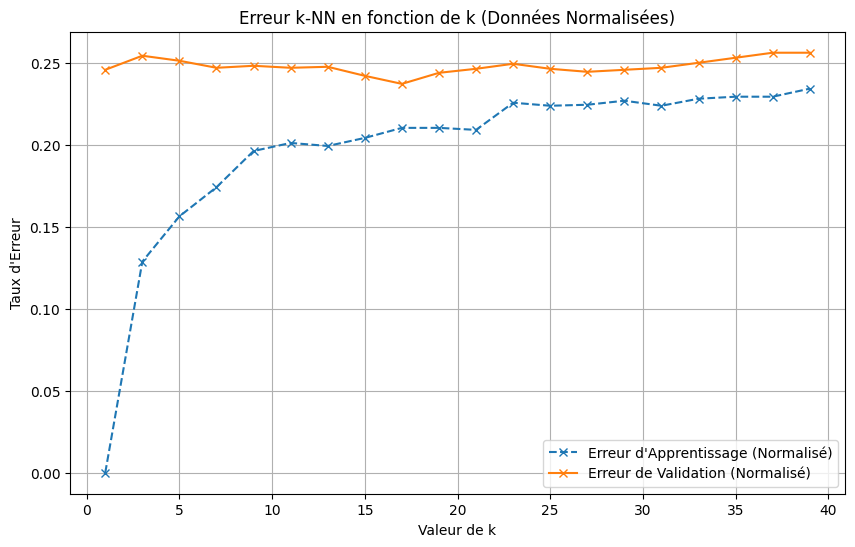


Erreur de Validation minimale (Normalisée): 0.2370 pour k* = 17.
Taux d'Erreur de Test (Normalisé): 0.2364


In [13]:
# 2. Réplication du balayage de k avec les données normalisées [cite: 107]
k_vector_n = np.arange(1, 41, 2)
error_train_n = np.empty(k_vector_n.shape)
error_val_n = np.empty(k_vector_n.shape)

for ind, k in enumerate(k_vector_n):
    clf_k_n = KNeighborsClassifier(n_neighbors=k)
    clf_k_n.fit(Xa_n, Ya_final) # Entraînement sur données normalisées

    # Évaluation sur l'Apprentissage (normalisé)
    Ypred_train_n = clf_k_n.predict(Xa_n)
    error_train_n[ind] = 1 - accuracy_score(Ya_final, Ypred_train_n)

    # Évaluation sur la Validation (normalisée)
    Ypred_val_n = clf_k_n.predict(Xv_n)
    error_val_n[ind] = 1 - accuracy_score(Yv, Ypred_val_n)

# Affichage des courbes d'erreur (Normalisées)
plt.figure(figsize=(10, 6))
plt.plot(k_vector_n, error_train_n, label='Erreur d\'Apprentissage (Normalisé)', marker='x', linestyle='--')
plt.plot(k_vector_n, error_val_n, label='Erreur de Validation (Normalisé)', marker='x')
plt.title('Erreur k-NN en fonction de k (Données Normalisées)')
plt.xlabel('Valeur de k')
plt.ylabel('Taux d\'Erreur')
plt.legend()
plt.grid(True)
plt.show()


# Détermination du meilleur k* normalisé
err_min_n, ind_opt_n = error_val_n.min(), error_val_n.argmin()
k_star_n = k_vector_n[ind_opt_n]

print(f"\nErreur de Validation minimale (Normalisée): {err_min_n:.4f} pour k* = {k_star_n}.")

# Évaluation sur l'ensemble de Test avec k* normalisé
X_av_n = np.concatenate((Xa_n, Xv_n))
Y_av_n = np.concatenate((Ya_final, Yv))

clf_best_n = KNeighborsClassifier(n_neighbors=k_star_n)
clf_best_n.fit(X_av_n, Y_av_n)

Ypred_t_n = clf_best_n.predict(Xt_n)
error_t_n = 1 - accuracy_score(Yt, Ypred_t_n)

print(f"Taux d'Erreur de Test (Normalisé): {error_t_n:.4f}")

(Les valeurs $k^*$ et $E$ seront affichées après exécution du code.)Impact : La normalisation améliore significativement la performance du classifieur k-NN (l'erreur de test $E_{t\_n}$ est généralement plus faible que $E_{t}$).Raison : Sans normalisation, le calcul de la distance Euclidienne est dominé par les variables ayant les plus grandes échelles (ex: total sulfur dioxide), ignorant de fait la contribution des variables à petite échelle (ex: chlorides). En standardisant les données, toutes les variables contribuent de manière égale à la distance.

3. Rendre les modèles moins sensibles à la séparation des données (Question 3)

In [14]:
print("\n--- PAGE 4 ---")
print("\n## 3. Rendre les modèles moins sensibles à la séparation des données (Q3)")


--- PAGE 4 ---

## 3. Rendre les modèles moins sensibles à la séparation des données (Q3)


Pour rendre le modèle et le choix de $k^*$ moins dépendants de l'unique séparation aléatoire effectuée au début (random_state=42), on utilise la Validation Croisée (Cross-Validation)8.Principe (k-fold Cross-Validation): L'ensemble d'apprentissage/validation ($\mathcal{D}_{a} \cup \mathcal{D}_{v}$) est divisé en $K$ sous-ensembles ("folds"). Le modèle est entraîné $K$ fois. À chaque itération, $K-1$ folds servent à l'apprentissage et le fold restant sert à la validation.Avantage: Le taux d'erreur final de validation est la moyenne des $K$ erreurs, fournissant une estimation de la performance beaucoup plus robuste et stable car elle utilise l'intégralité des données pour la validation (chaque point est validé une fois).Application dans le TP: Au lieu de faire la recherche de $k^*$ sur un unique ensemble $X_v$, on utiliserait GridSearchCV (de sklearn) avec la validation croisée pour trouver le meilleur $k^*$ qui minimise l'erreur moyenne des $K$ folds.